# 04 - Which failure does node telemetry actually predict?

`eda/` reported that `NODE_FAIL` - the one state that unambiguously means *the machine
broke*, the literal subject of this thesis - was indistinguishable from chance. That
conclusion rested on **107 jobs**, of which 36 produced a window. It was never a
statement about node failures; it was a statement about 36 jobs.

The cluster holds **1,426 `NODE_FAIL` jobs, 651 of them scorable**. Every failure mode
is now large enough to be given its own detector instead of being pooled into a single
"failure" label that `eda/` showed is 70 % walltime exhaustion.

This notebook does two things:

1. **A detector per failure mode**, telemetry against job context, so the question
   "what does the telemetry know?" gets a separate answer for each mechanism instead of
   one answer dominated by the most common one.
2. **The pooled protocol**, run the same way as `headroom/05`, so the headline number of
   this project can be quoted on the whole cluster rather than on 51 nodes.

## Pre-registration

**V1 - the pooled model is still a walltime detector.** At the selected configuration,
`TIMEOUT` lift will exceed hardware-failure lift by more than 5x, as it did on GPU nodes
(29.8x against 2.1x).

**V2 - `TIMEOUT` is still a human artefact.** On non-GPU nodes, more than 80 % of
`TIMEOUT` jobs will have run for within 60 seconds of a whole number of hours, against
under 5 % of `COMPLETED` jobs. This replicates `eda/`'s GPU finding (92.6 % vs 1.9 %) on
a population that shares none of its jobs.

**V3 - telemetry wins somewhere.** With every mode now above 600 jobs, node telemetry
will beat job context on **at least one** failure mode. On GPU nodes it beat context on
none of them once the calendar columns were removed.

**V4 - `NODE_FAIL` stops being chance.** A dedicated `NODE_FAIL` detector will reach a
validation job-level AP above **2x** its base rate. `eda/` measured it at chance on 36
jobs.

In [1]:
# --- Setup ------------------------------------------------------------------
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

WINDOW, SNAP_S = 40, 30.0
FLOOR_S  = (WINDOW // 2 - 1) * SNAP_S
DEC      = 4
VAL_FRAC = 0.20
HORIZONS = [0.5, 1.0, 2.0, 4.0]
MIN_VAL_POS = 500                      # headroom/05's eligibility guard, unchanged
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
HARDWARE = ("FAILED", "OUT_OF_MEMORY", "NODE_FAIL")
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts_01 = json.load(open(DATA / "facts_01.json"))
FEATURES = facts_01["features"]
facts = {}

In [2]:
t0 = time.time()
META = ["slurm_id", "state", "gpu_node", "split", "ttf_end", "w_idx",
        "t_end", "nodetypes", "numnodes"]
pf = pq.ParquetFile(DATA / "windows_all.parquet")
chunks = []
for batch in pf.iter_batches(batch_size=400_000, columns=META + FEATURES):
    d = batch.to_pandas()
    chunks.append(d[d.w_idx % DEC == 0])
w = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()
jobs = pd.read_parquet(DATA / "jobs_all.parquet")
w = w.merge(jobs[["slurm_id", "start_date", "numcores"]], on="slurm_id", how="left")

el = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = el / 3600.0
w["sec_into_hour"]       = el % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (el % 3600.0)
w["elapsed_hours_floor"] = np.floor(el / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
C7 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"]
SETS = {"T36 telemetry": FEATURES, "C7  context": C7, "T36+C7 both": FEATURES + C7}

tr_jobs = (w.loc[w.split == "train", ["slurm_id", "t_end"]]
             .groupby("slurm_id").t_end.max().sort_values())
val_ids = set(tr_jobs.index[int(len(tr_jobs) * (1 - VAL_FRAC)):])
w["fold"] = np.where(w.split == "test", "test",
             np.where(w.slurm_id.isin(val_ids), "val", "fit"))
M = {f: (w.fold == f).to_numpy() for f in ["fit", "val", "test"]}
state = w.state.to_numpy()
ttf = w.ttf_end.to_numpy()
print(f"{len(w):,} windows | {w.slurm_id.nunique():,} jobs | [{time.time()-t0:.0f}s]")
print(w.groupby("fold").agg(windows=("ttf_end", "size"), jobs=("slurm_id", "nunique")).to_string())

2,052,964 windows | 92,054 jobs | [4s]
      windows   jobs
fold                
fit   1297062  60380
test   263877  16578
val    492025  15096


In [3]:
def label(H, states):
    """Window is positive if its own job ends in one of `states` within H hours."""
    return (np.isin(state, states) & (ttf >= 0)
            & (ttf <= H * 3600 - FLOOR_S)).astype(np.int8)

def job_ap(mask, score, states):
    sub = w.loc[mask, ["slurm_id", "state"]]
    d = pd.DataFrame({"slurm_id": sub.slurm_id.to_numpy(),
                      "state": sub.state.astype(str).to_numpy(), "score": score})
    g = d.groupby("slurm_id").agg(score=("score", "max"), state=("state", "first"))
    yj = g.state.isin(states).astype(int).to_numpy()
    return average_precision_score(yj, g.score.to_numpy()), float(yj.mean()), yj, g

def run(fit_mask, cols, eval_mask, y, states):
    m = lgb.LGBMClassifier(**PARAMS).fit(w.loc[fit_mask, cols], y[fit_mask])
    sc = m.predict_proba(w.loc[eval_mask, cols])[:, 1]
    jap, base, yj, g = job_ap(eval_mask, sc, states)
    return m, sc, jap, base, yj, g

## Step 1 - One detector per failure mode

Four separate models, each trained against a single mechanism. A window is positive only
if **its own job** ends in that state within the horizon; every other window, including
windows from jobs that failed a different way, is negative. Job-level AP is measured
against that state alone.

This is the table `eda/` could not produce: at 107 `NODE_FAIL` jobs and 130
`OUT_OF_MEMORY` jobs, three of these four cells were noise.

In [4]:
t0 = time.time()
H_MODE = 2.0
rows = []
for st in FAILURE_STATES:
    y = label(H_MODE, [st])
    npos_fit, npos_val = int(y[M["fit"]].sum()), int(y[M["val"]].sum())
    njobs = int(w.loc[M["val"] & (state == st), "slurm_id"].nunique())
    for name, cols in SETS.items():
        _, sc, jap, base, yj, _ = run(M["fit"], cols, M["val"], y, [st])
        rows.append(dict(fail_mode=st, features=name, val_job_ap=jap, base=base,
                         lift=jap / base if base else np.nan,
                         val_pos_windows=npos_val, val_jobs=int(yj.sum()),
                         fit_pos_windows=npos_fit))
    print(f"  {st:14s} val jobs {njobs:5,}  [{time.time()-t0:.0f}s]")
Mo = pd.DataFrame(rows)
Mo.to_csv(DATA / "per_mode.csv", index=False)
print()
print("VALIDATION job-level AP, one detector per mode (2 h horizon)")
print(Mo.pivot(index="fail_mode", columns="features", values="val_job_ap").round(4).to_string())
print()
print("the same, as a multiple of that mode's base rate")
print(Mo.pivot(index="fail_mode", columns="features", values="lift").round(2).to_string())
print()
print(Mo.groupby("fail_mode")[["base", "val_jobs"]].first().round(5).to_string())

  FAILED         val jobs   618  [59s]


  TIMEOUT        val jobs 3,376  [114s]


  OUT_OF_MEMORY  val jobs   120  [167s]


  NODE_FAIL      val jobs   251  [224s]

VALIDATION job-level AP, one detector per mode (2 h horizon)
features       C7  context  T36 telemetry  T36+C7 both
fail_mode                                             
FAILED              0.0369         0.0666       0.0765
NODE_FAIL           0.0591         0.0329       0.0306
OUT_OF_MEMORY       0.0330         0.0384       0.0532
TIMEOUT             0.7574         0.7200       0.7948

the same, as a multiple of that mode's base rate
features       C7  context  T36 telemetry  T36+C7 both
fail_mode                                             
FAILED                0.90           1.63         1.87
NODE_FAIL             3.55           1.98         1.84
OUT_OF_MEMORY         4.15           4.84         6.69
TIMEOUT               3.39           3.22         3.55

                  base  val_jobs
fail_mode                       
FAILED         0.04094       618
NODE_FAIL      0.01663       251
OUT_OF_MEMORY  0.00795       120
TIMEOUT        0.22364

In [5]:
tel = Mo[Mo.features == "T36 telemetry"].set_index("fail_mode").val_job_ap
ctx = Mo[Mo.features == "C7  context"].set_index("fail_mode").val_job_ap
wins = [m for m in FAILURE_STATES if tel[m] > ctx[m]]
v3 = len(wins) > 0
nf_lift = float(Mo[(Mo.fail_mode == "NODE_FAIL")].lift.max())
v4 = nf_lift > 2.0
print(f"V3  telemetry beats context on some mode : {'CONFIRMED' if v3 else 'REJECTED'}")
print(f"    modes where telemetry wins: {wins if wins else 'none'}")
for m_ in FAILURE_STATES:
    print(f"      {m_:14s} telemetry {tel[m_]:.4f}  context {ctx[m_]:.4f}  "
          f"{'telemetry' if tel[m_] > ctx[m_] else 'context'}")
print(f"V4  NODE_FAIL above 2x its base rate     : {'CONFIRMED' if v4 else 'REJECTED'}")
print(f"    best NODE_FAIL detector {nf_lift:.2f}x")
facts.update(V3=bool(v3), V4=bool(v4), telemetry_wins=wins,
             node_fail_lift=nf_lift,
             per_mode_telemetry={k: float(v) for k, v in tel.items()},
             per_mode_context={k: float(v) for k, v in ctx.items()})

V3  telemetry beats context on some mode : CONFIRMED
    modes where telemetry wins: ['FAILED', 'OUT_OF_MEMORY']
      FAILED         telemetry 0.0666  context 0.0369  telemetry
      TIMEOUT        telemetry 0.7200  context 0.7574  context
      OUT_OF_MEMORY  telemetry 0.0384  context 0.0330  telemetry
      NODE_FAIL      telemetry 0.0329  context 0.0591  context
V4  NODE_FAIL above 2x its base rate     : CONFIRMED
    best NODE_FAIL detector 3.55x


## Step 2 - The pooled protocol, run on the whole cluster

Identical to `headroom/05`: a horizon is eligible only with at least 500 validation
positives, selection is on **validation job-level average precision** because a job's
label does not move when the horizon does, and lift is never a selection criterion.

In [6]:
t0 = time.time()
rows = []
for H in HORIZONS:
    y = label(H, FAILURE_STATES)
    npos = int(y[M["val"]].sum())
    if npos < MIN_VAL_POS:
        print(f"H={H:4.2f} h  val positives {npos} < {MIN_VAL_POS} - INELIGIBLE")
        continue
    for name, cols in SETS.items():
        _, sc, jap, base, yj, _ = run(M["fit"], cols, M["val"], y, FAILURE_STATES)
        rows.append(dict(horizon_h=H, features=name, val_pos=npos, val_job_ap=jap,
                         val_job_base=base, val_win_ap=average_precision_score(y[M["val"]], sc)))
    print(f"H={H:4.2f} h  val positives {npos:>8,}  [{time.time()-t0:.0f}s]")
V = pd.DataFrame(rows)
V.to_csv(DATA / "selection_all.csv", index=False)
print()
print("VALIDATION job-level AP")
print(V.pivot(index="horizon_h", columns="features", values="val_job_ap").round(4).to_string())

H=0.50 h  val positives    5,615  [54s]


H=1.00 h  val positives   12,200  [107s]


H=2.00 h  val positives   20,922  [161s]


H=4.00 h  val positives   33,667  [216s]

VALIDATION job-level AP
features   C7  context  T36 telemetry  T36+C7 both
horizon_h                                         
0.5             0.7368         0.6791       0.7216
1.0             0.7205         0.6601       0.7395
2.0             0.7434         0.6925       0.7431
4.0             0.7546         0.7077       0.7508


In [7]:
best = V.loc[V.val_job_ap.idxmax()]
BEST_H, BEST_SET = float(best.horizon_h), str(best.features)
print(f"SELECTED -> horizon {BEST_H} h, features {BEST_SET}, "
      f"validation job AP {best.val_job_ap:.4f}")

yB = label(BEST_H, FAILURE_STATES)
trm = M["fit"] | M["val"]
m_best, sc_t, jap_t, base_t, yj_t, gj = run(trm, SETS[BEST_SET], M["test"], yB, FAILURE_STATES)

def ap_ci(y, s, n_boot=300, seed=1):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if y[i].sum():
            out.append(average_precision_score(y[i], s[i]))
    return np.percentile(out, [2.5, 97.5])

lo_, hi_ = ap_ci(yj_t, gj.score.to_numpy())
print(f"TEST job-level AP {jap_t:.4f}  95 % CI [{lo_:.4f}, {hi_:.4f}]  "
      f"base {base_t:.4%}  ->  {jap_t/base_t:.2f}x")
print(f"  validation {best.val_job_ap:.4f} -> test {jap_t:.4f}  "
      f"(shrinkage {best.val_job_ap/jap_t:.2f}x)")
print(f"  {int(yj_t.sum()):,} failing jobs among {len(yj_t):,} scorable test jobs")
facts.update(selected_horizon_h=BEST_H, selected_features=BEST_SET,
             test_job_ap=float(jap_t), test_job_ap_lo=float(lo_),
             test_job_ap_hi=float(hi_), test_base=float(base_t),
             test_lift=float(jap_t / base_t), test_jobs=int(len(yj_t)),
             test_failing_jobs=int(yj_t.sum()))

SELECTED -> horizon 4.0 h, features C7  context, validation job AP 0.7546


TEST job-level AP 0.4641  95 % CI [0.4511, 0.4772]  base 28.9661%  ->  1.60x
  validation 0.7546 -> test 0.4641  (shrinkage 1.63x)
  4,802 failing jobs among 16,578 scorable test jobs


In [8]:
sj = gj.score.to_numpy(); order = np.argsort(-sj)
rows = []
for k in [10, 25, 50, 100, 200, 400, 800, 1600]:
    if k > len(order):
        continue
    hit = int(yj_t[order[:k]].sum())
    rows.append(dict(flagged=k, precision=hit / k, recall=hit / yj_t.sum(), true_alerts=hit))
OP = pd.DataFrame(rows)
print("Operating points on test")
print(OP.round(4).to_string(index=False))
facts["operating_points"] = OP.to_dict("records")

# where do the alerts land, by mode
gj2 = gj.copy(); gj2["rank"] = (-gj2.score).rank(method="first")
top = gj2[gj2["rank"] <= 200]
print()
print("what the top 200 alerts actually are")
print(top.state.value_counts().to_string())

Operating points on test
 flagged  precision  recall  true_alerts
      10     1.0000  0.0021           10
      25     1.0000  0.0052           25
      50     1.0000  0.0104           50
     100     1.0000  0.0208          100
     200     0.9850  0.0410          197
     400     0.9525  0.0793          381
     800     0.9075  0.1512          726
    1600     0.5863  0.1953          938

what the top 200 alerts actually are
state
TIMEOUT      194
NODE_FAIL      3
COMPLETED      3


In [9]:
# --- is it still a walltime detector? --------------------------------------
te = w[M["test"]].copy(); te["score"] = sc_t
rows = []
for st in FAILURE_STATES:
    keep = (te.state == st) | (te.state == "COMPLETED")
    sub = te[keep]
    yj_m = (sub.groupby("slurm_id").state.first() == st).astype(int).to_numpy()
    sc_m = sub.groupby("slurm_id").score.max().to_numpy()
    ap = average_precision_score(yj_m, sc_m)
    rows.append(dict(fail_mode=st, job_ap=ap, base=yj_m.mean(), lift=ap / yj_m.mean(),
                     jobs=int(yj_m.sum())))
PM = pd.DataFrame(rows)
print("the selected pooled model, evaluated one mode at a time against COMPLETED")
print(PM.round(4).to_string(index=False))
t_lift = float(PM[PM.fail_mode == "TIMEOUT"].lift.iloc[0])
h_lift = float(PM[PM.fail_mode.isin(HARDWARE)].lift.mean())
v1 = t_lift > 5 * h_lift
print()
print(f"V1  still a walltime detector : {'CONFIRMED' if v1 else 'REJECTED'}")
print(f"    TIMEOUT {t_lift:.2f}x  vs  hardware failures {h_lift:.2f}x average")
facts.update(V1=bool(v1), timeout_lift=t_lift, hardware_lift=h_lift)

the selected pooled model, evaluated one mode at a time against COMPLETED
    fail_mode  job_ap   base   lift  jobs
       FAILED  0.1147 0.1073 1.0690  1415
      TIMEOUT  0.4744 0.1856 2.5557  2684
OUT_OF_MEMORY  0.0346 0.0230 1.5070   277
    NODE_FAIL  0.0403 0.0349 1.1537   426

V1  still a walltime detector : REJECTED
    TIMEOUT 2.56x  vs  hardware failures 1.24x average


## Step 3 - Does the TIMEOUT artefact replicate off the GPU nodes?

`eda/` showed that 92.6 % of GPU `TIMEOUT` jobs ran for within 60 seconds of a whole
number of hours, against 1.9 % of `COMPLETED` jobs - the signature of a person typing a
round number into a submission script, not of hardware slowing a job down. If that holds
on 10,625 non-GPU `TIMEOUT` jobs, it is a property of how people use clusters, and it is
the reason `TIMEOUT` cannot be pooled with hardware failure anywhere in this project.

In [10]:
J = jobs.copy()
J["dur"] = (J.end_date - J.start_date).dt.total_seconds()
J = J[J.dur > 0]
off = np.minimum(J.dur % 3600, 3600 - (J.dur % 3600))
J["round_hour"] = off <= 60
grp = np.where(J.gpu_node == 1, "GPU", "non-GPU")
R = (J.groupby([grp, "state"]).round_hour.agg(["mean", "size"]) * [100, 1])
print("% of jobs whose runtime is within 60 s of a whole number of hours")
print(R.rename(columns={"mean": "pct_round", "size": "jobs"}).round(2).to_string())
ng_t = float(R.loc[("non-GPU", "TIMEOUT"), "mean"])
ng_c = float(R.loc[("non-GPU", "COMPLETED"), "mean"])
v2 = ng_t > 80 and ng_c < 5
print()
print(f"V2  TIMEOUT is a human artefact off GPU nodes : {'CONFIRMED' if v2 else 'REJECTED'}")
print(f"    non-GPU TIMEOUT {ng_t:.1f} %  vs  COMPLETED {ng_c:.1f} %   "
      f"(GPU nodes: 92.6 % vs 1.9 %)")
facts.update(V2=bool(v2), timeout_round_nongpu=ng_t, completed_round_nongpu=ng_c)

% of jobs whose runtime is within 60 s of a whole number of hours
                       pct_round    jobs
        state                           
GPU     COMPLETED           7.70   17306
        FAILED             52.06    4664
        NODE_FAIL          10.28     107
        OUT_OF_MEMORY       9.23     130
        TIMEOUT            87.60    1411
non-GPU COMPLETED          34.74  202874
        FAILED             49.46   37582
        NODE_FAIL           4.70    1426
        OUT_OF_MEMORY      17.23    4499
        TIMEOUT            53.95   10625

V2  TIMEOUT is a human artefact off GPU nodes : REJECTED
    non-GPU TIMEOUT 53.9 %  vs  COMPLETED 34.7 %   (GPU nodes: 92.6 % vs 1.9 %)


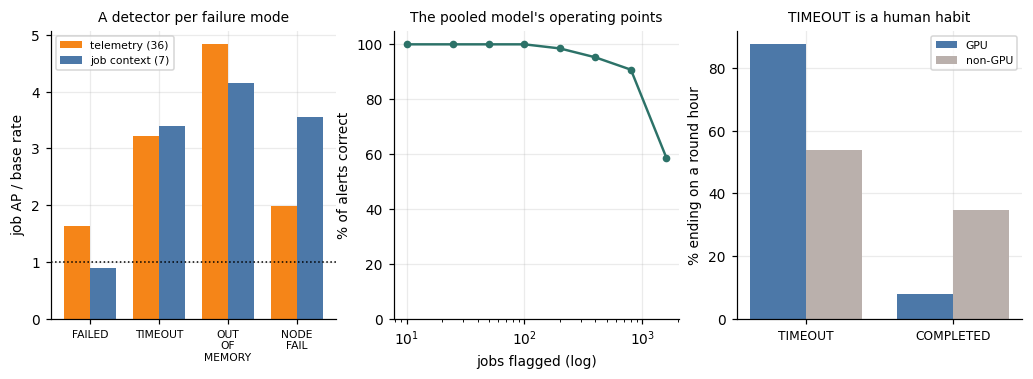

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4))

ax = axes[0]
x = np.arange(len(FAILURE_STATES))
ax.bar(x - .19, [tel[m] / Mo[Mo.fail_mode == m].base.iloc[0] for m in FAILURE_STATES], .38,
       label="telemetry (36)", color="#f58518")
ax.bar(x + .19, [ctx[m] / Mo[Mo.fail_mode == m].base.iloc[0] for m in FAILURE_STATES], .38,
       label="job context (7)", color="#4c78a8")
ax.axhline(1, color="k", ls=":", lw=1)
ax.set_xticks(x); ax.set_xticklabels([s.replace("_", "\n") for s in FAILURE_STATES],
                                     fontsize=7)
ax.set_ylabel("job AP / base rate"); ax.legend(fontsize=7)
ax.set_title("A detector per failure mode", fontsize=9)

ax = axes[1]
ax.plot(OP.flagged, OP.precision * 100, marker="o", ms=4, color="#2c7268", lw=1.6)
ax.set_xscale("log"); ax.set_xlabel("jobs flagged (log)")
ax.set_ylabel("% of alerts correct"); ax.set_ylim(0, 105)
ax.set_title("The pooled model's operating points", fontsize=9)

ax = axes[2]
sub = R.reset_index().rename(columns={"level_0": "grp"})
for i, g in enumerate(["GPU", "non-GPU"]):
    d = sub[sub.grp == g].set_index("state").reindex(["TIMEOUT", "COMPLETED"])
    ax.bar(np.arange(2) + (i - .5) * .38, d["mean"], .38, label=g,
           color=["#4c78a8", "#bab0ac"][i])
ax.set_xticks([0, 1]); ax.set_xticklabels(["TIMEOUT", "COMPLETED"], fontsize=8)
ax.set_ylabel("% ending on a round hour"); ax.legend(fontsize=7)
ax.set_title("TIMEOUT is a human habit", fontsize=9)
save(fig, "04_verdict.png"); plt.show()

## Step 4 - The four verdicts together

In [12]:
json.dump(facts, open(DATA / "facts_04.json", "w"), indent=1)
for k in ["V1", "V2", "V3", "V4"]:
    print(f"{k}  {'CONFIRMED' if facts[k] else 'REJECTED'}")
print()
for k, v in facts.items():
    if k not in ("operating_points",):
        print(f"{k:26s} {v}")

V1  REJECTED
V2  REJECTED
V3  CONFIRMED
V4  CONFIRMED

V3                         True
V4                         True
telemetry_wins             ['FAILED', 'OUT_OF_MEMORY']
node_fail_lift             3.553823932321725
per_mode_telemetry         {'FAILED': 0.06659943564011002, 'TIMEOUT': 0.7199728035574181, 'OUT_OF_MEMORY': 0.038434453319482156, 'NODE_FAIL': 0.032889951388690386}
per_mode_context           {'FAILED': 0.03685874622248732, 'TIMEOUT': 0.7573768372774139, 'OUT_OF_MEMORY': 0.032951186491020155, 'NODE_FAIL': 0.059089149908104995}
selected_horizon_h         4.0
selected_features          C7  context
test_job_ap                0.46407501572913956
test_job_ap_lo             0.4511492753920408
test_job_ap_hi             0.47721813381948996
test_base                  0.2896609965013874
test_lift                  1.6021315307700283
test_jobs                  16578
test_failing_jobs          4802
V1                         False
timeout_lift               2.555705249956039
hardware